/tmp/ipykernel_3777630/3643161962.py:106: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  d["origin"] = folder


missing-Y filter   : 11596 -> 2002
design-prefix dedup: 2002 -> 1013

designs: 1013   naturals: 8
group
NaN                       707
BALM-deployed (len 15)    212
Control (len 15)           61
Other len-15 designs       41
Name: count, dtype: int64 

pairwise alignments: 520,710
  50,000/520,710
  100,000/520,710
  150,000/520,710
  200,000/520,710
  250,000/520,710
  300,000/520,710
  350,000/520,710
  400,000/520,710
  450,000/520,710
  500,000/520,710
[cache] wrote /FastHome/gyula/designs/place_holder/logo_plots/pairwise_cache.npz
[saved] /FastHome/gyula/designs/place_holder/logo_plots/logo_all.png


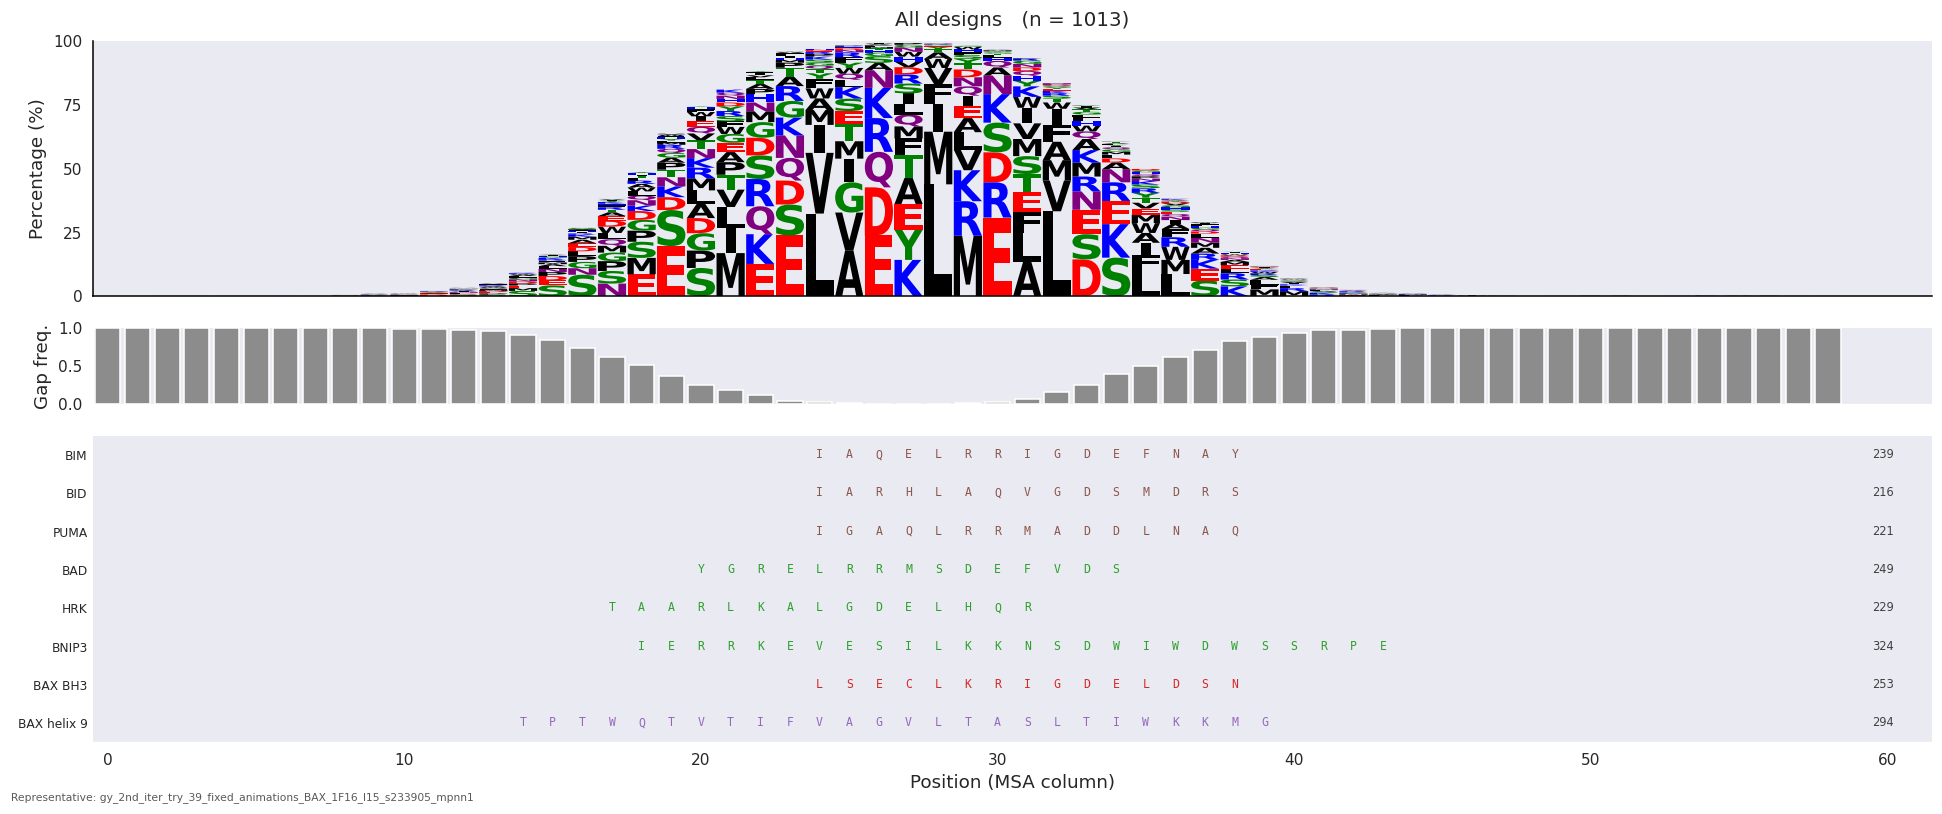

  [note] Some residues were clipped during PSSM alignment for: ['PUMA']
[saved] /FastHome/gyula/designs/place_holder/logo_plots/logo_ntoc_1.png


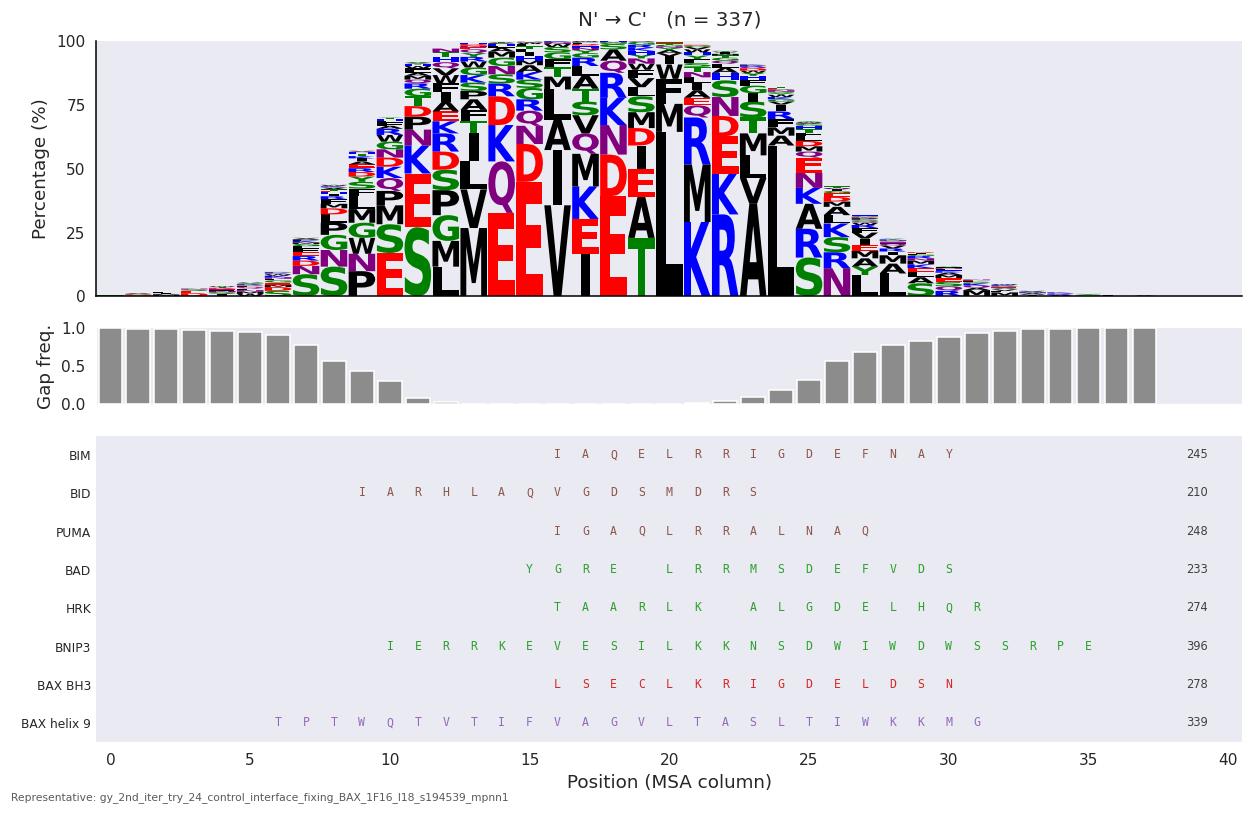

[saved] /FastHome/gyula/designs/place_holder/logo_plots/logo_ntoc_0.png


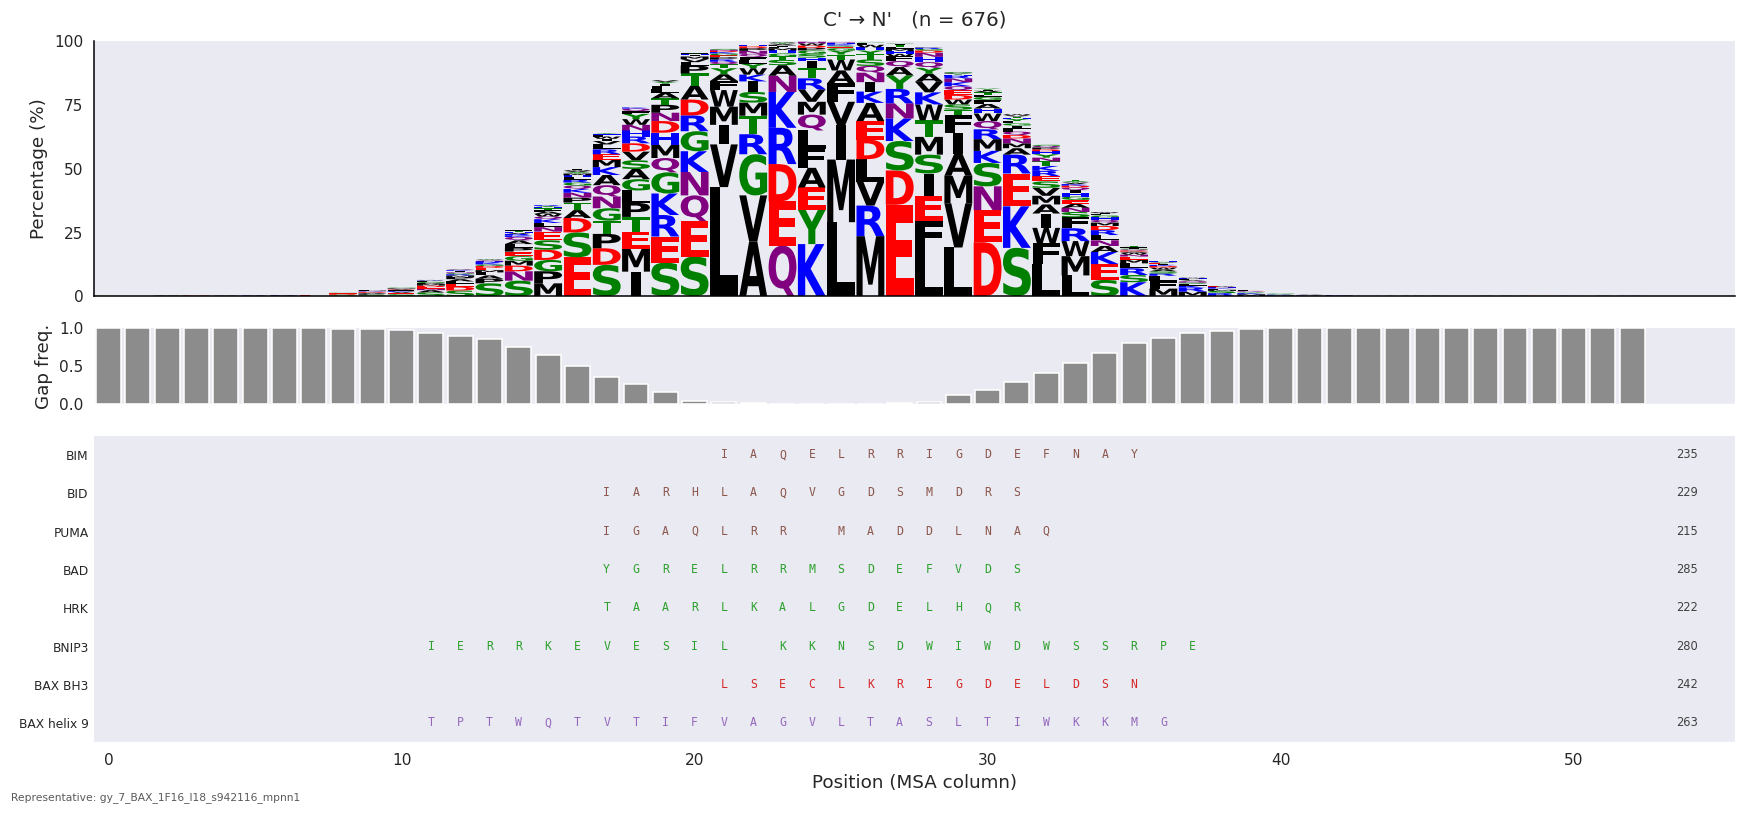

  [note] Some residues were clipped during PSSM alignment for: ['BAD', 'BAX BH3', 'BAX helix 9', 'BIM', 'BNIP3', 'PUMA']
[saved] /FastHome/gyula/designs/place_holder/logo_plots/logo_balm_deployed_ntoc_1.png


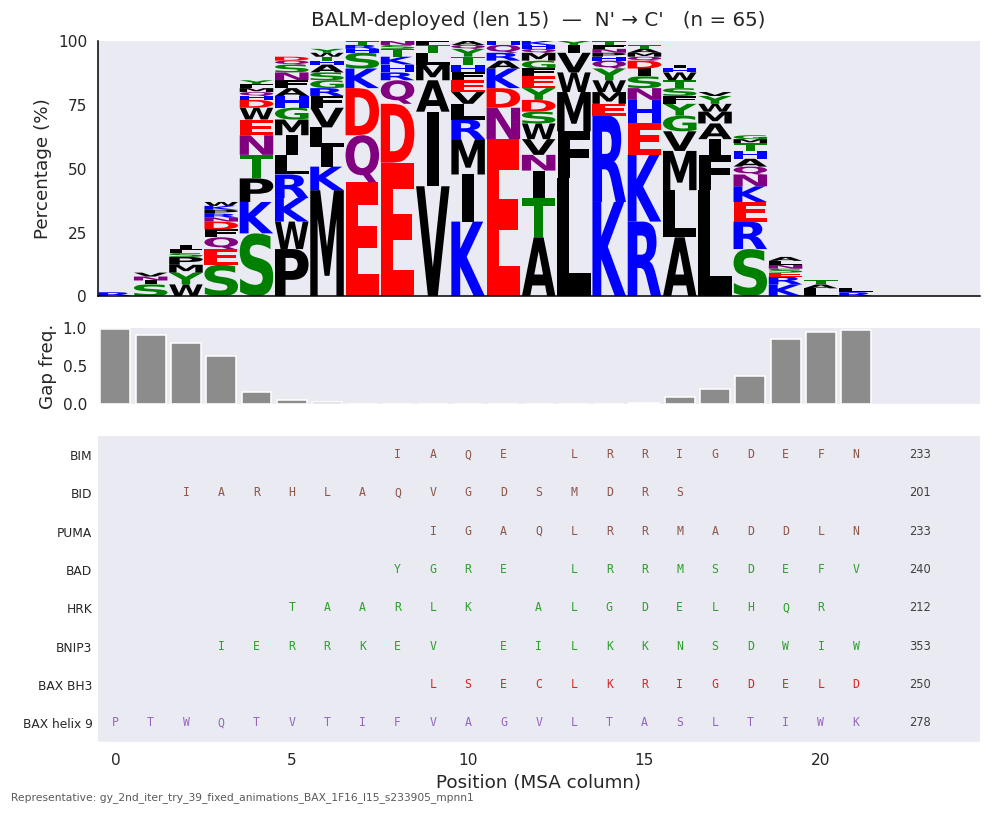

  [note] Some residues were clipped during PSSM alignment for: ['BAX helix 9', 'BNIP3']
[saved] /FastHome/gyula/designs/place_holder/logo_plots/logo_balm_deployed_ntoc_0.png


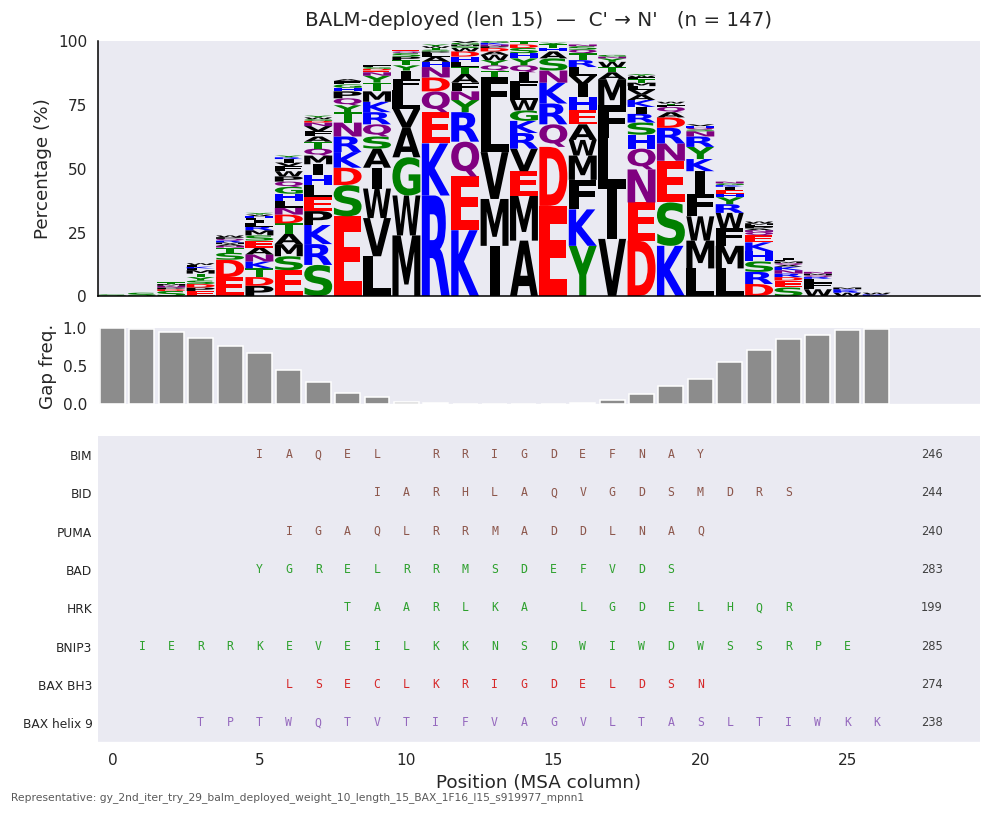

  [note] Some residues were clipped during PSSM alignment for: ['BAD', 'BAX BH3', 'BAX helix 9', 'BIM', 'BNIP3', 'HRK', 'PUMA']
[saved] /FastHome/gyula/designs/place_holder/logo_plots/logo_control_ntoc_1.png


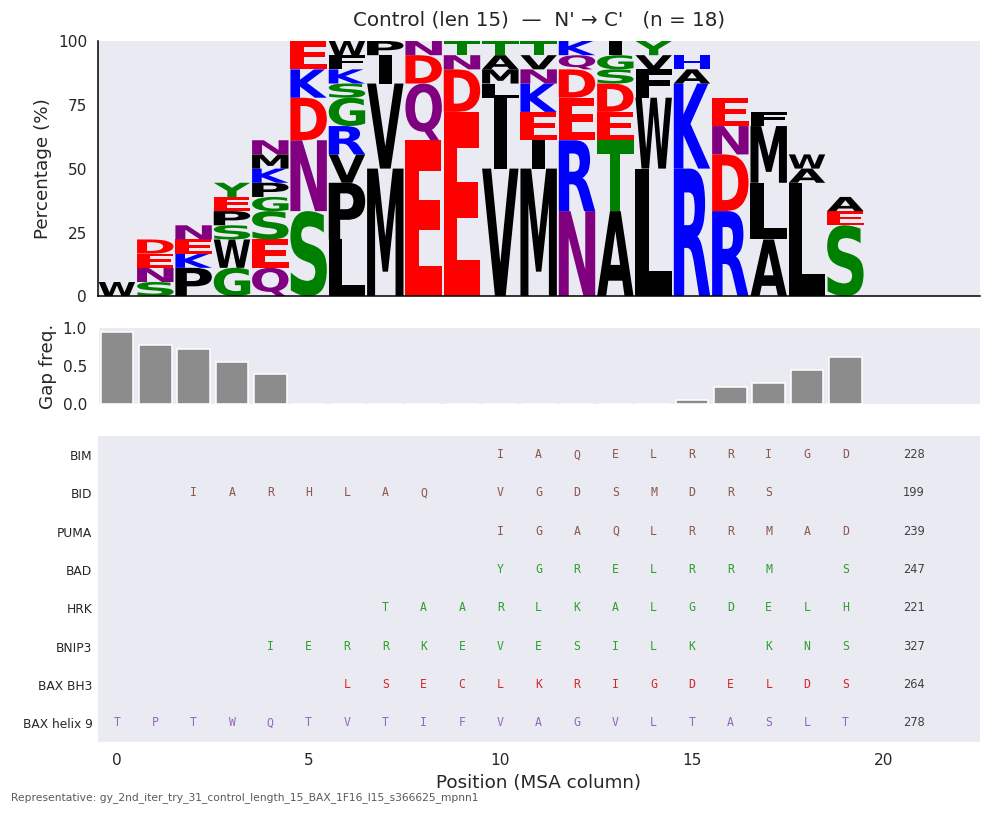

  [note] Some residues were clipped during PSSM alignment for: ['BAX helix 9', 'BNIP3']
[saved] /FastHome/gyula/designs/place_holder/logo_plots/logo_control_ntoc_0.png


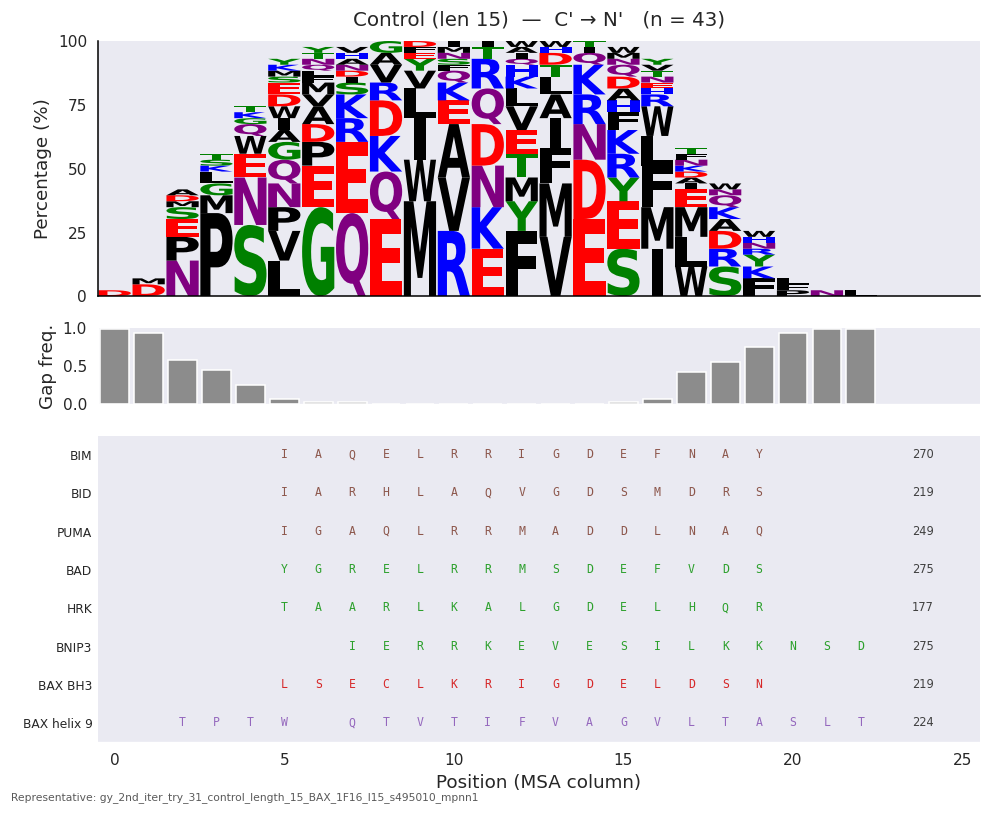

  [note] Some residues were clipped during PSSM alignment for: ['BAD', 'BAX helix 9', 'BID', 'BNIP3']
[saved] /FastHome/gyula/designs/place_holder/logo_plots/logo_other_ntoc_1.png


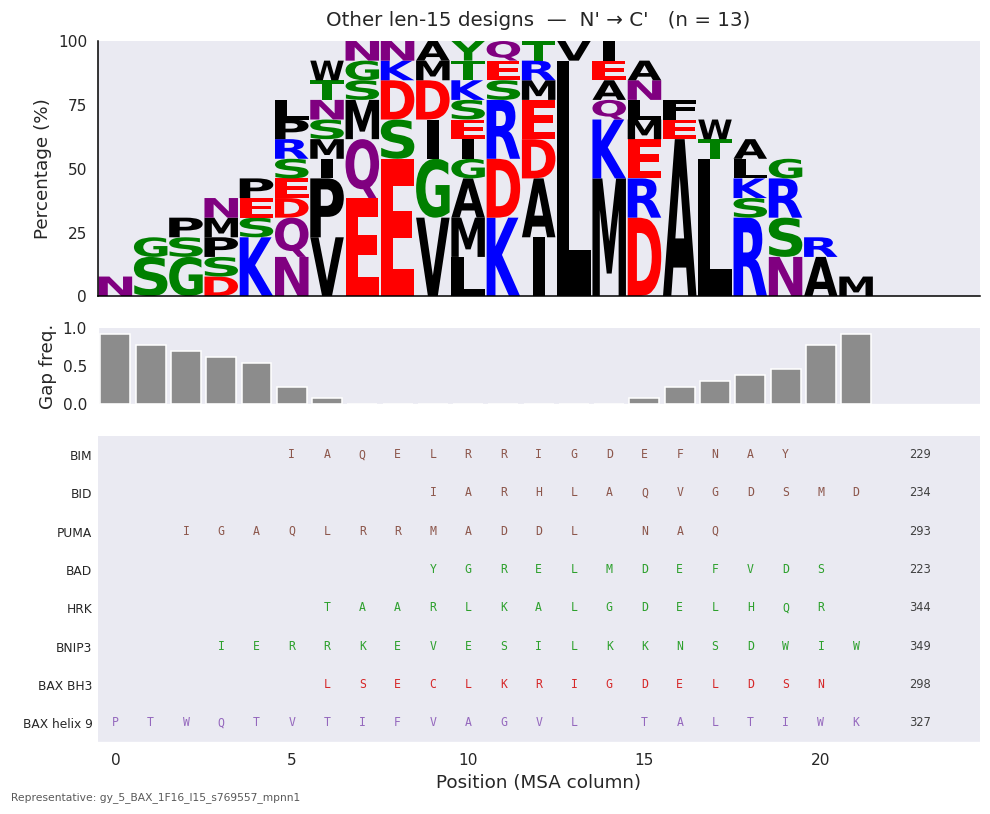

  [note] Some residues were clipped during PSSM alignment for: ['BNIP3']
[saved] /FastHome/gyula/designs/place_holder/logo_plots/logo_other_ntoc_0.png


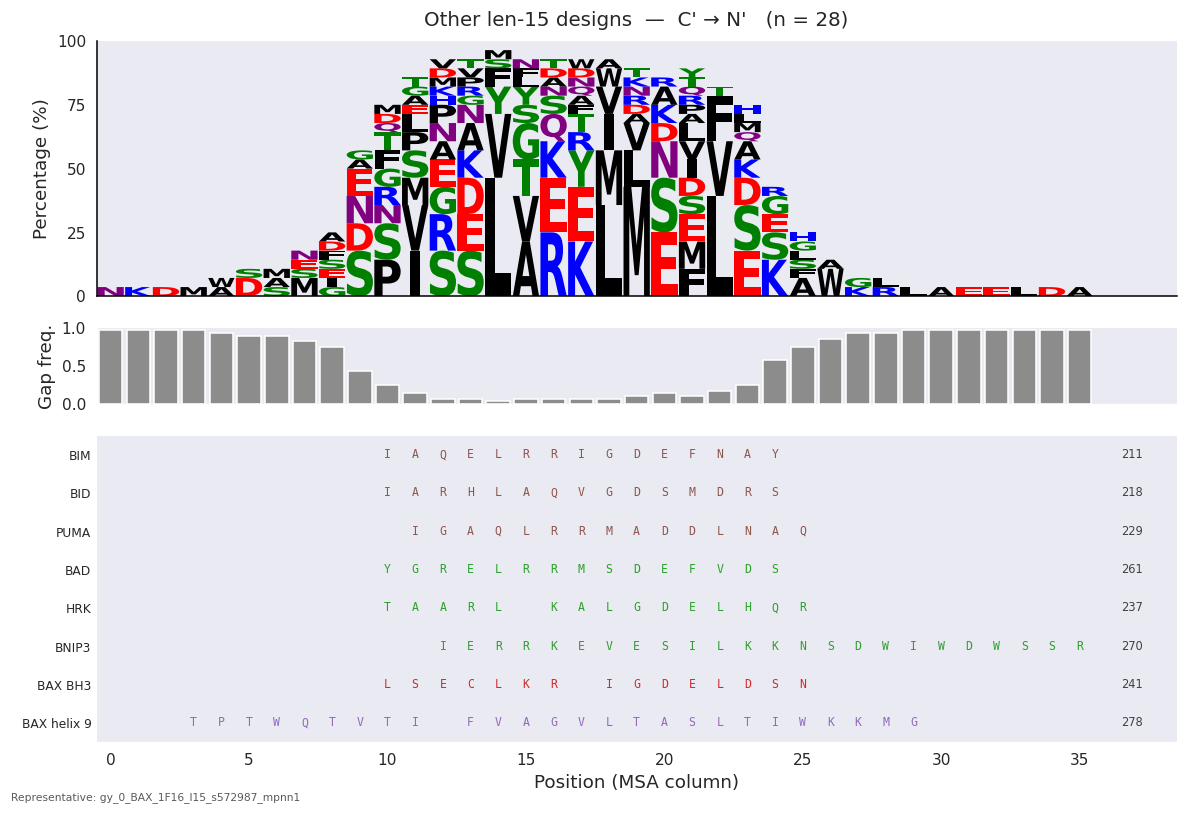

/FastHome/gyula/anaconda3/envs/gyula_env/lib/python3.14/site-packages/umap/umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")
/FastHome/gyula/anaconda3/envs/gyula_env/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


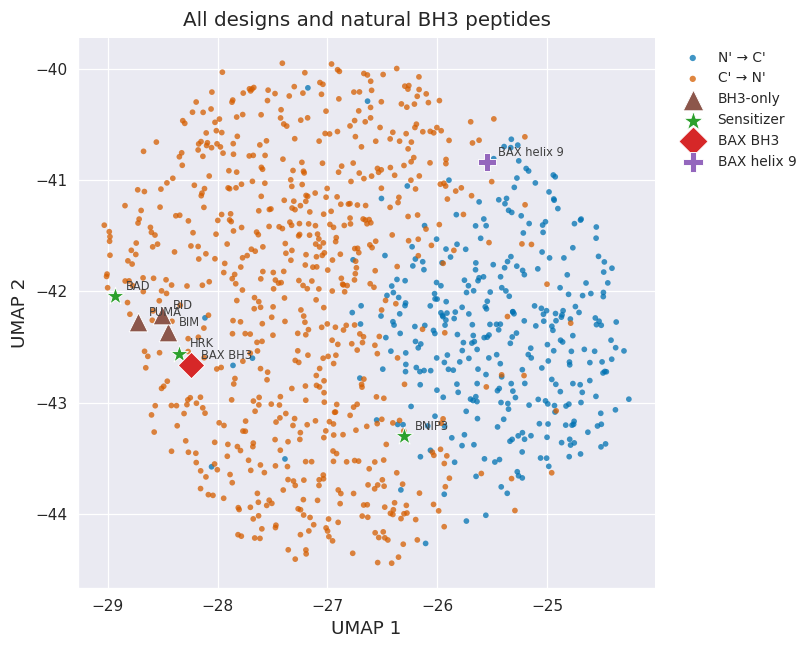

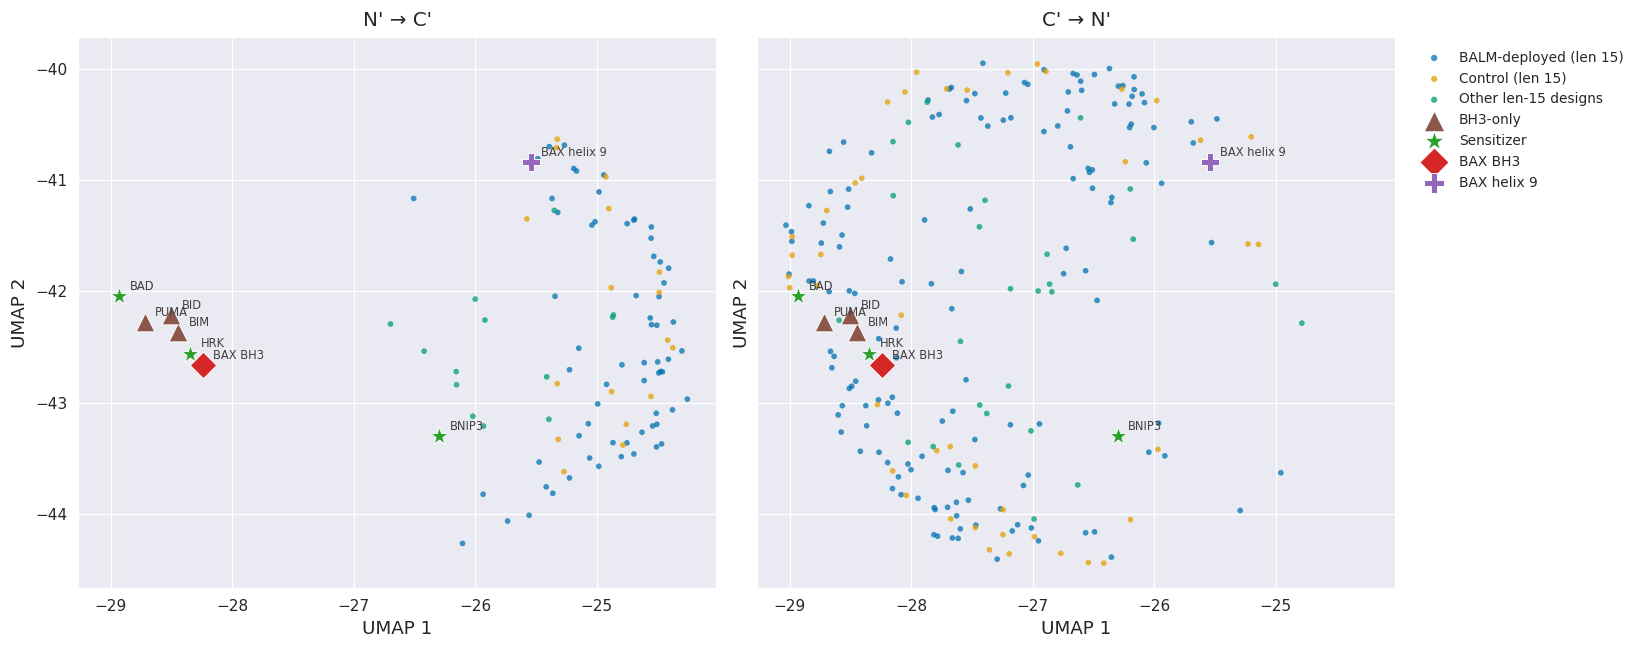


in namespace: df_all, df_umap, records, scores, offsets, padded_all, padded_by_ntoc, padded_by_group_ntoc, distance_matrix, embedding, design_idx, nat_idx, nat_meta


In [7]:
"""
MPNN design stats -> filtering -> pairwise scores -> MSA + logos + UMAP,
with natural BH3 reference peptides carried through the whole pipeline.

Run with:  %run -i design_analysis.py
Every intermediate stays in the notebook namespace.
"""

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import logomaker
import umap
from Bio import motifs, Align
from Bio.Align import substitution_matrices
from Bio.Data import IUPACData
from Bio.Seq import Seq
from Bio.SeqRecord import SeqRecord

# ==========================================================================
# Config
# ==========================================================================
BASE = Path("/FastHome/gyula/designs/place_holder/DATA")
CSV_NAME = "mpnn_design_stats_augmented_with_ntoc.csv"
OUT_DIR = Path("/FastHome/gyula/designs/place_holder/logo_plots")
CACHE = OUT_DIR / "pairwise_cache.npz"
USE_CACHE = False

FOLDERS = [
    "gy_0", "gy_2", "gy_4", "gy_5", "gy_7",
    "gy_11_mut_5", "gy_13_maybe_mut_20", "gy_14_more_iter", "j_1",
    "gy_2nd_iter_1",
    "gy_2nd_iter_try_23_balm_deployed",
    "gy_2nd_iter_try_24_control_interface_fixing",
    "gy_2nd_iter_try_29_balm_deployed_weight_10_length_15",
    "gy_2nd_iter_try_40_fixed_new_filters",
    "gy_2nd_iter_try_31_control_length_15",
    "gy_2nd_iter_try_39_fixed_animations",
    "gy_2nd_iter_try_41_more_iter",
]
FOLDERS = list(dict.fromkeys(FOLDERS))

SEQ_COL, DESIGN_COL, NTOC_COL, Y_COL = "Sequence", "Design", "n_to_c", "Y"
GAP_PENALTY = -100_000_000

NTOC_LABELS = {1: "N' \u2192 C'", 0: "C' \u2192 N'"}

TARGET_LENGTH = 15
GROUP1_FOLDERS = [
    "gy_2nd_iter_try_29_balm_deployed_weight_10_length_15",
    "gy_2nd_iter_try_40_fixed_new_filters",
    "gy_2nd_iter_try_39_fixed_animations",
    "gy_2nd_iter_try_41_more_iter",
]
GROUP2_FOLDERS = ["gy_2nd_iter_try_31_control_length_15"]

G1 = "BALM-deployed (len 15)"
G2 = "Control (len 15)"
G3 = "Other len-15 designs"
GROUP_ORDER = [G1, G2, G3]
GROUP_COLORS = {G1: "#0072B2", G2: "#E69F00", G3: "#009E73"}

REQUIRE_LENGTH_FOR_G1_G2 = False

NATURALS = [
    ("BIM",         "IAQELRRIGDEFNAY", "BH3-only"),
    ("BID",         "IARHLAQVGDSMDRS", "BH3-only"),
    ("PUMA",        "IGAQLRRMADDLNAQ", "BH3-only"),
    ("BAD",         "YGRELRRMSDEFVDS", "Sensitizer"),
    ("HRK",         "TAARLKALGDELHQR", "Sensitizer"),
    ("BNIP3",       "IERRKEVESILKKNSDWIWDWSSRPE", "Sensitizer"),
    ("BAX BH3",     "LSECLKRIGDELDSN", "BAX BH3"),
    ("BAX helix 9", "TPTWQTVTIFVAGVLTASLTIWKKMG", "BAX helix 9"),
]
NAT_STYLE = {
    "BH3-only":    ("#8C564B", "^"),
    "Sensitizer":  ("#2CA02C", "*"),
    "BAX BH3":     ("#D62728", "D"),
    "BAX helix 9": ("#9467BD", "P"),
}

plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 600, "savefig.bbox": "tight",
    "font.family": "sans-serif", "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "axes.labelsize": 12, "axes.titlesize": 13, "axes.linewidth": 0.9,
    "xtick.labelsize": 10, "ytick.labelsize": 10, "legend.fontsize": 9,
    "legend.frameon": False, "pdf.fonttype": 42, "ps.fonttype": 42,
})
sns.set_palette("colorblind")


# ==========================================================================
# Helpers
# ==========================================================================
def load_all(folders=FOLDERS, base=BASE, csv_name=CSV_NAME):
    frames = []
    for folder in folders:
        path = base / folder / csv_name
        if not path.is_file():
            print(f"[skip] missing: {path}")
            continue
        d = pd.read_csv(path)
        d["origin"] = folder
        frames.append(d)
    if not frames:
        raise FileNotFoundError("No CSVs found under " + str(base))
    return pd.concat(frames, ignore_index=True)


def filter_designs(d):
    n0 = len(d)
    d = d.dropna(subset=[Y_COL, SEQ_COL, DESIGN_COL]).copy()
    print(f"missing-Y filter   : {n0} -> {len(d)}")
    d["design_prefix"] = d[DESIGN_COL].astype(str).str.rsplit("_", n=1).str[0]
    n1 = len(d)
    d = d.drop_duplicates(subset=["origin", "design_prefix"], keep="first")
    print(f"design-prefix dedup: {n1} -> {len(d)}")
    return d.reset_index(drop=True)


def assign_group(row):
    if row["kind"] != "design":
        return np.nan
    ok_len = row["length"] == TARGET_LENGTH
    if row["origin"] in GROUP1_FOLDERS:
        return G1 if (ok_len or not REQUIRE_LENGTH_FOR_G1_G2) else np.nan
    if row["origin"] in GROUP2_FOLDERS:
        return G2 if (ok_len or not REQUIRE_LENGTH_FOR_G1_G2) else np.nan
    return G3 if ok_len else np.nan


def create_my_aligner(BLOSUM=True, gap_penalty=-10):
    aligner = Align.PairwiseAligner()
    aligner.mode = "global"
    if BLOSUM:
        aligner.substitution_matrix = substitution_matrices.load("BLOSUM80")
        aligner.open_gap_score = gap_penalty * 2
        aligner.extend_gap_score = gap_penalty
    aligner.end_insertion_score = 0
    aligner.end_deletion_score = 0
    return aligner


def get_relative_offset(aligned_ref, aligned_new):
    ref_start = len(aligned_ref) - len(aligned_ref.lstrip("-"))
    new_start = len(aligned_new) - len(aligned_new.lstrip("-"))
    return new_start - ref_start


def compute_pairwise(recs, BLOSUM=True, gap_penalty=GAP_PENALTY, verbose=True):
    aligner = create_my_aligner(BLOSUM=BLOSUM, gap_penalty=gap_penalty)
    n = len(recs)
    scores = np.zeros((n, n))
    offsets = np.zeros((n, n), dtype=int)
    total = n * (n - 1) // 2
    if verbose:
        print(f"pairwise alignments: {total:,}")
    done = 0
    for i in range(n):
        for j in range(i + 1, n):
            aln = aligner.align(recs[i].seq, recs[j].seq)[0]
            scores[i, j] = scores[j, i] = aln.score
            off = get_relative_offset(str(aln[0]), str(aln[1]))
            offsets[i, j], offsets[j, i] = off, -off
            done += 1
            if verbose and total > 20000 and done % 50000 == 0:
                print(f"  {done:,}/{total:,}", flush=True)
    return scores, offsets


def rigid_msa(recs, scores, offsets, idx):
    idx = list(idx)
    n = len(idx)
    sub = scores[np.ix_(idx, idx)]
    lengths = [len(recs[k].seq) for k in idx]

    id1, id2 = np.unravel_index(np.argmax(sub), sub.shape)
    global_offsets = {id1: 0, id2: int(offsets[idx[id1], idx[id2]])}
    pool, todo = {id1, id2}, set(range(n)) - {id1, id2}

    while todo:
        best, pair = -np.inf, None
        for u in todo:
            for a in pool:
                if sub[u, a] > best:
                    best, pair = sub[u, a], (u, a)
        new_id, ref_id = pair
        global_offsets[new_id] = global_offsets[ref_id] + int(
            offsets[idx[ref_id], idx[new_id]])
        pool.add(new_id)
        todo.remove(new_id)

    lo = min(global_offsets.values())
    for k in global_offsets:
        global_offsets[k] -= lo
    msa_len = max(global_offsets[k] + lengths[k] for k in range(n))

    padded = ["-" * global_offsets[k] + str(recs[idx[k]].seq)
              + "-" * (msa_len - lengths[k] - global_offsets[k])
              for k in range(n)]
    return padded, global_offsets


def centroid(scores, idx):
    sub = scores[np.ix_(list(idx), list(idx))]
    return int(np.argmax(sub.sum(axis=1)))

def align_seq_to_pssm(seq_str, pssm_df, gap_penalty=-20, coverage_bonus=5.0):
    """
    Semi-global (ends-free) alignment of a sequence to a PERCENTAGE matrix
    (0-100 scale, NOT log-odds). `coverage_bonus` still rewards longer
    alignments over short, dense hits, rescaled for the percentage scale.
    """
    L = len(pssm_df)
    N = len(seq_str)
    score = np.zeros((L + 1, N + 1))
    ptr = np.zeros((L + 1, N + 1), dtype=int)

    for i in range(1, L + 1):
        score[i, 0] = 0
        ptr[i, 0] = 1
    for j in range(1, N + 1):
        score[0, j] = 0
        ptr[0, j] = 2

    for i in range(1, L + 1):
        for j in range(1, N + 1):
            aa = seq_str[j-1]
            # Direct percentage value at this column/residue (0-100),
            # not log2(freq/background) as before.
            match = (pssm_df.at[i-1, aa] if aa in pssm_df.columns else 0.0) + coverage_bonus

            diag = score[i-1, j-1] + match
            up = score[i-1, j] + gap_penalty
            left = score[i, j-1] + gap_penalty

            best = max(diag, up, left)
            score[i, j] = best
            if best == diag:   ptr[i, j] = 0
            elif best == up:   ptr[i, j] = 1
            else:              ptr[i, j] = 2

    max_score = -np.inf
    end_i, end_j = L, N
    for j in range(0, N + 1):
        if score[L, j] > max_score:
            max_score = score[L, j]
            end_i, end_j = L, j
    for i in range(0, L + 1):
        if score[i, N] > max_score:
            max_score = score[i, N]
            end_i, end_j = i, N

    alignment = []
    i, j = end_i, end_j
    while i > 0 and j > 0:
        if ptr[i, j] == 0:
            i -= 1
            j -= 1
            alignment.append((i, seq_str[j]))
        elif ptr[i, j] == 1:
            i -= 1
        else:
            j -= 1

    return alignment[::-1], max_score


def logo_with_naturals(padded, idx, recs, scores, nat_idx, nat_meta,
                       title, save_path=None):
    n_seq = len(padded)
    L = len(padded[0])

    gap_freq = np.array([sum(s[i] == "-" for s in padded)
                         for i in range(L)]) / n_seq

    m = motifs.create([Seq(s) for s in padded],
                  alphabet=IUPACData.protein_letters + "-")
    raw_counts = pd.DataFrame(m.counts)
    raw_counts = raw_counts.drop(columns=["-"], errors="ignore")

    mat_pct = raw_counts / n_seq * 100.0

    rep_local = centroid(scores, idx)
    rep_global = idx[rep_local]

    n_nat = len(nat_idx)
    fig, (ax_logo, ax_gap, ax_nat) = plt.subplots(
        nrows=3, ncols=1, sharex=True,
        figsize=(max(9, 0.30 * L), 5.0 + 0.30 * n_nat),
        gridspec_kw={"height_ratios": [3, 0.9, 0.45 * n_nat]})

    logo = logomaker.Logo(mat_pct, color_scheme="chemistry",
                          stack_order="small_on_top", ax=ax_logo)
    logo.style_spines(visible=False)
    logo.style_spines(spines=("left", "bottom"), visible=True)
    ax_logo.set_ylabel("Percentage (%)")
    ax_logo.set_ylim(0, 100)
    ax_logo.set_yticks([0, 25, 50, 75, 100])
    ax_logo.set_title(f"{title}   (n = {n_seq})", pad=10)
    ax_logo.grid(False)

    ax_gap.bar(range(L), gap_freq, color="0.55", width=0.85)
    ax_gap.set_ylabel("Gap freq.")
    ax_gap.set_ylim(0, 1.0)
    ax_gap.set_yticks([0, 0.5, 1.0])
    ax_gap.spines[["top", "right"]].set_visible(False)
    ax_gap.grid(False)

    clipped = []
    for row, gi in enumerate(nat_idx):
        name, fam = nat_meta[gi]
        colour = NAT_STYLE[fam][0]
        seq_str = str(recs[gi].seq)

        # Align against the percentage matrix directly
        alignment, aln_score = align_seq_to_pssm(seq_str, mat_pct)

        if len(alignment) < len(seq_str):
            clipped.append(name)

        for pos, ch in alignment:
            if 0 <= pos < L:
                ax_nat.text(pos, -row, ch, ha="center", va="center",
                            fontsize=7.5, family="monospace", color=colour)

        ax_nat.text(L + 0.5, -row, f"{aln_score:.0f}", ha="left", va="center",
                    fontsize=7.5, color="0.25")

    if clipped:
        print(f"  [note] Some residues were clipped during PSSM alignment for: {sorted(set(clipped))}")

    ax_nat.set_ylim(-n_nat + 0.5, 0.5)
    ax_nat.set_yticks([-r for r in range(n_nat)])
    ax_nat.set_yticklabels([nat_meta[gi][0] for gi in nat_idx], fontsize=8)
    ax_nat.set_xlim(-0.5, L + 2.5)
    ax_nat.set_xlabel("Position (MSA column)")
    ax_nat.spines[["top", "right", "left"]].set_visible(False)
    ax_nat.tick_params(axis="y", length=0)
    ax_nat.grid(False)

    fig.text(0.005, 0.01, f"Representative: {recs[rep_global].id}",
             fontsize=7, color="0.35")
    plt.tight_layout()
    if save_path:
        Path(save_path).parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_path)
        fig.savefig(str(save_path).replace(".png", ".pdf"))
        print(f"[saved] {save_path}")
    plt.show()


def scores_to_distance(scores):
    dist = scores.max() - scores
    np.fill_diagonal(dist, 0.0)
    return dist


def umap_panel(ax, data, hue_col, palette, title, nat_df, legend=True):
    present = set(data[hue_col].dropna())
    for key in [k for k in palette if k in present]:
        sub = data[data[hue_col] == key]
        ax.scatter(sub["UMAP1"], sub["UMAP2"], s=14, alpha=0.75,
                   c=palette[key], edgecolors="none", label=key, zorder=2)

    for fam, (colour, marker) in NAT_STYLE.items():
        sub = nat_df[nat_df["family"] == fam]
        if sub.empty:
            continue
        ax.scatter(sub["UMAP1"], sub["UMAP2"], c=colour, marker=marker,
                   s=150, edgecolors="white", linewidths=0.6,
                   zorder=5, label=fam)

    for _, r in nat_df.iterrows():
        ax.annotate(r["name"], (r["UMAP1"], r["UMAP2"]),
                    textcoords="offset points", xytext=(7, 4),
                    fontsize=7.5, color="0.25", zorder=6)

    ax.set_xlabel("UMAP 1")
    ax.set_ylabel("UMAP 2")
    ax.set_title(title, pad=8)
    if legend:
        ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", markerscale=1.1)
    sns.despine(ax=ax)


# ==========================================================================
# STEP 1 -- designs + naturals into one frame
# ==========================================================================
df_raw = load_all()
df_designs = filter_designs(df_raw)
df_designs["kind"] = "design"
df_designs["name"] = (df_designs["origin"] + "_"
                      + df_designs[DESIGN_COL].astype(str))
df_designs["family"] = np.nan

df_nat = pd.DataFrame({
    "name": [n for n, _, _ in NATURALS],
    SEQ_COL: [s for _, s, _ in NATURALS],
    "family": [f for _, _, f in NATURALS],
    "origin": [f for _, _, f in NATURALS],
    "kind": "natural",
})

df_all = pd.concat([df_designs, df_nat], ignore_index=True)
df_all["length"] = df_all[SEQ_COL].astype(str).str.strip().str.len()
df_all["group"] = df_all.apply(assign_group, axis=1)
df_all[f"{NTOC_COL}_label"] = df_all[NTOC_COL].map(NTOC_LABELS)

records = [SeqRecord(Seq(str(r[SEQ_COL]).strip().upper()),
                     id=str(r["name"]), description=str(r["origin"]))
           for _, r in df_all.iterrows()]

design_idx = df_all.index[df_all["kind"] == "design"].tolist()
nat_idx = df_all.index[df_all["kind"] == "natural"].tolist()
nat_meta = {i: (df_all.at[i, "name"], df_all.at[i, "family"]) for i in nat_idx}

OUT_DIR.mkdir(parents=True, exist_ok=True)
df_all.to_csv(OUT_DIR / "unified_designs.csv", index=False)
print(f"\ndesigns: {len(design_idx)}   naturals: {len(nat_idx)}")
print(df_all["group"].value_counts(dropna=False), "\n")


# ==========================================================================
# STEP 2 -- the one expensive pass (cached)
# ==========================================================================
if USE_CACHE and CACHE.is_file():
    _c = np.load(CACHE)
    scores, offsets = _c["scores"], _c["offsets"]
    if scores.shape[0] != len(records):
        raise ValueError(
            f"cache holds {scores.shape[0]} sequences, current set has "
            f"{len(records)}. Delete {CACHE} or set USE_CACHE = False.")
    print(f"[cache] loaded {CACHE}")
else:
    scores, offsets = compute_pairwise(records)
    np.savez_compressed(CACHE, scores=scores, offsets=offsets)
    print(f"[cache] wrote {CACHE}")


# ==========================================================================
# STEP 3 -- logos: all designs, then by n_to_c
# ==========================================================================
padded_all, _ = rigid_msa(records, scores, offsets, design_idx)
logo_with_naturals(padded_all, design_idx, records, scores,
                   nat_idx, nat_meta, "All designs",
                   OUT_DIR / "logo_all.png")

padded_by_ntoc = {}
for value, label in NTOC_LABELS.items():
    idx = df_all.index[(df_all["kind"] == "design")
                       & (df_all[NTOC_COL] == value)].tolist()
    if len(idx) < 2:
        print(f"[skip] {label}: fewer than 2 sequences")
        continue
    padded_by_ntoc[value], _ = rigid_msa(records, scores, offsets, idx)
    logo_with_naturals(padded_by_ntoc[value], idx, records, scores,
                       nat_idx, nat_meta, label,
                       OUT_DIR / f"logo_ntoc_{value}.png")


# ==========================================================================
# STEP 4 -- logos: group x n_to_c  (3 x 2)
# ==========================================================================
padded_by_group_ntoc = {}
for grp in GROUP_ORDER:
    for value, label in NTOC_LABELS.items():
        idx = df_all.index[(df_all["group"] == grp)
                           & (df_all[NTOC_COL] == value)].tolist()
        if len(idx) < 2:
            print(f"[skip] {grp} / {label}: {len(idx)} sequence(s)")
            continue
        padded, _ = rigid_msa(records, scores, offsets, idx)
        padded_by_group_ntoc[(grp, value)] = padded
        stem = grp.split()[0].lower().replace("-", "_")
        logo_with_naturals(padded, idx, records, scores,
                           nat_idx, nat_meta, f"{grp}  \u2014  {label}",
                           OUT_DIR / f"logo_{stem}_ntoc_{value}.png")


# ==========================================================================
# STEP 5 -- UMAP (one embedding, reused across every panel)
# ==========================================================================
distance_matrix = scores_to_distance(scores)
reducer = umap.UMAP(metric="precomputed", n_neighbors=50, random_state=42)
embedding = reducer.fit_transform(distance_matrix)

df_all["UMAP1"], df_all["UMAP2"] = embedding[:, 0], embedding[:, 1]
df_umap = df_all
df_umap.to_csv(OUT_DIR / "umap_coords.csv", index=False)

nat_df = df_umap[df_umap["kind"] == "natural"]
ntoc_palette = {NTOC_LABELS[k]: c
                for k, c in zip(NTOC_LABELS, ["#0072B2", "#D55E00"])}

# 5a. overview, coloured by direction
fig, ax = plt.subplots(figsize=(7.5, 6))
umap_panel(ax, df_umap[df_umap["kind"] == "design"], f"{NTOC_COL}_label",
           ntoc_palette, "All designs and natural BH3 peptides", nat_df)
plt.tight_layout()
plt.savefig(OUT_DIR / "umap_all.png")
plt.savefig(OUT_DIR / "umap_all.pdf")
plt.show()

# 5b. two panels: coloured by group, split by n_to_c
fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharex=True, sharey=True)
for ax, (value, label) in zip(axes, NTOC_LABELS.items()):
    sub = df_umap[(df_umap["kind"] == "design") & (df_umap[NTOC_COL] == value)]
    umap_panel(ax, sub, "group", GROUP_COLORS, label, nat_df,
               legend=(ax is axes[-1]))
plt.tight_layout()
plt.savefig(OUT_DIR / "umap_groups_by_ntoc.png")
plt.savefig(OUT_DIR / "umap_groups_by_ntoc.pdf")
plt.show()

print("\nin namespace: df_all, df_umap, records, scores, offsets, "
      "padded_all, padded_by_ntoc, padded_by_group_ntoc, "
      "distance_matrix, embedding, design_idx, nat_idx, nat_meta")

/FastHome/gyula/anaconda3/envs/gyula_env/lib/python3.14/site-packages/umap/umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")
/FastHome/gyula/anaconda3/envs/gyula_env/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/FastHome/gyula/anaconda3/envs/gyula_env/lib/python3.14/site-packages/umap/umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")
/FastHome/gyula/anaconda3/envs/gyula_env/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


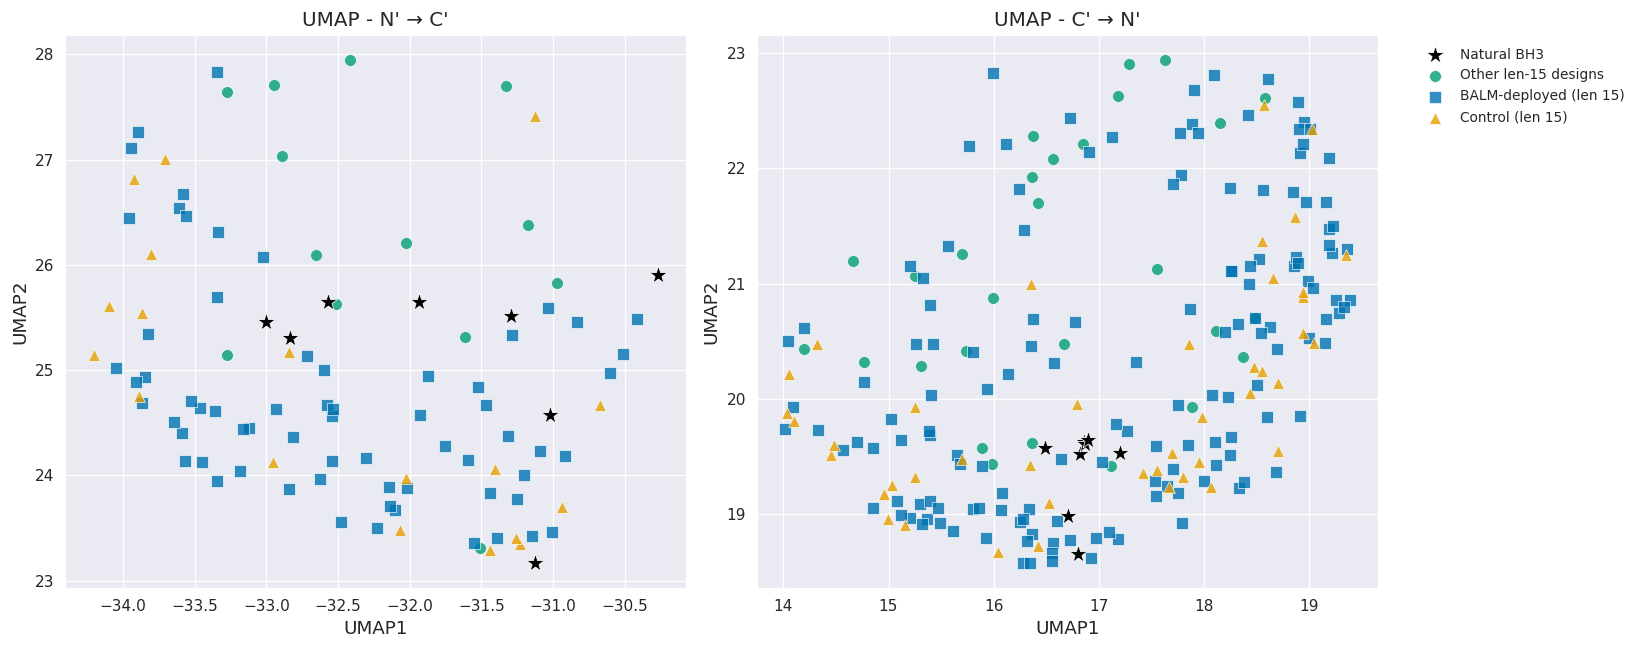


in namespace: df_all, df_umap, records, scores, offsets, distance_matrix, design_idx, nat_idx, nat_meta


In [13]:
import numpy as np
import pandas as pd
import umap
import matplotlib.pyplot as plt

distance_matrix = scores_to_distance(scores)

# Optional length mask (set to True if dataframe already filtered to 15-mers)
length_mask = True

df_umap_list = []

# 1. Fit separate UMAPs and compile coordinates
for value, label in NTOC_LABELS.items():

    # Designs for this orientation
    is_target_design = (df_all["kind"] == "design") & (df_all[NTOC_COL] == value)

    # Check if natural peptides have a specific orientation column.
    # If not (or if it's NaN), we include all natural peptides in BOTH plots as reference.
    if NTOC_COL in df_all.columns and not df_all.loc[df_all["kind"]=="natural", NTOC_COL].isna().all():
        is_target_natural = (df_all["kind"] == "natural") & (df_all[NTOC_COL] == value)
    else:
        is_target_natural = (df_all["kind"] == "natural")

    mask = (is_target_design | is_target_natural) & length_mask
    idx = np.where(mask)[0]

    if len(idx) == 0:
        continue

    # Subset distance matrix and fit
    sub_dist_matrix = distance_matrix[np.ix_(idx, idx)]
    reducer = umap.UMAP(metric="precomputed", n_neighbors=20, random_state=42)
    embedding = reducer.fit_transform(sub_dist_matrix)

    # Save to a sub-dataframe so natural peptides get independent coords for each panel
    df_sub = df_all.iloc[idx].copy()
    df_sub["UMAP1"] = embedding[:, 0]
    df_sub["UMAP2"] = embedding[:, 1]
    df_sub["Panel_Label"] = label

    df_umap_list.append(df_sub)

# Combine into a new dataframe and save
df_umap = pd.concat(df_umap_list, ignore_index=True)
df_umap.to_csv(OUT_DIR / "umap_coords_split.csv", index=False)

# 2. Setup shapes for the groups
available_markers = ['o', 's', '^', 'D', 'v', '<', '>', 'p', 'h', 'X', 'd']
unique_groups = df_umap[df_umap["kind"] == "design"]["group"].dropna().unique()
# Assign a unique marker to each design group
GROUP_MARKERS = {grp: available_markers[i % len(available_markers)] for i, grp in enumerate(unique_groups)}

# 3. Plotting
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for ax, label in zip(axes, NTOC_LABELS.values()):
    panel_df = df_umap[df_umap["Panel_Label"] == label]

    # Plot Natural Peptides first (larger, distinct star shape, zorder=3 keeps them on top)
    nat_sub = panel_df[panel_df["kind"] == "natural"]
    if not nat_sub.empty:
        ax.scatter(nat_sub["UMAP1"], nat_sub["UMAP2"],
                   color="black", marker="*", s=150, label="Natural BH3",
                   edgecolors="white", linewidths=0.5, zorder=3)

    # Plot Designs group by group for color and shape mapping
    des_sub = panel_df[panel_df["kind"] == "design"]
    for grp in unique_groups:
        grp_data = des_sub[des_sub["group"] == grp]
        if grp_data.empty:
            continue

        color = GROUP_COLORS.get(grp, "gray") # Fallback to gray if group missing
        marker = GROUP_MARKERS.get(grp, "o")

        ax.scatter(grp_data["UMAP1"], grp_data["UMAP2"],
                   color=color, marker=marker, s=60, label=f"{grp}",
                   alpha=0.8, edgecolors="white", linewidths=0.5, zorder=2)

    ax.set_title(f"UMAP - {label}")
    ax.set_xlabel("UMAP1")
    ax.set_ylabel("UMAP2")

    # Add legend only to the rightmost panel
    if ax is axes[-1]:
        ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.savefig(OUT_DIR / "umap_groups_by_ntoc.png", dpi=300, bbox_inches='tight')
plt.savefig(OUT_DIR / "umap_groups_by_ntoc.pdf", bbox_inches='tight')
plt.show()

print("\nin namespace: df_all, df_umap, records, scores, offsets, "
      "distance_matrix, design_idx, nat_idx, nat_meta")